# Data Cleaning and Normalization for MOTM Prediction
## Làm sạch và chuẩn hóa dữ liệu cho dự đoán MOTM

Notebook này hướng dẫn chi tiết cách làm sạch và chuẩn hóa dữ liệu cho dự án dự đoán Man of The Match

## BLOCK 1: Cài đặt và Import thư viện

In [2]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import re
import warnings
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Tất cả thư viện đã được import thành công!")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ NumPy version: {np.__version__}")

✓ Tất cả thư viện đã được import thành công!
✓ Pandas version: 2.2.2
✓ NumPy version: 2.0.2


## BLOCK 2: Mount Google Drive (Nếu dùng Colab)

In [14]:
# Kiểm tra và mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    colab = True
    print("✓ Google Drive đã được mount thành công!")
except:
    colab = False
    print("✓ Không phải Google Colab - chạy local")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive đã được mount thành công!


## BLOCK 3: Cấu hình đường dẫn file

In [21]:
# ============ CẤU HÌNH ĐƯỜNG DẪN ============

if colab:
    # Đối với Google Colab - điều chỉnh path của bạn
    base_path = '/content/drive/MyDrive/Pl_MOTM'
    input_file = f'{base_path}/PlayerCrawl.xlsx'
    output_clean = f'{base_path}/PlayerCrawl_cleaned.xlsx'
    output_normalized = f'{base_path}/PlayerCrawl_normalized.xlsx'
    output_clean_csv = f'{base_path}/PlayerCrawl_cleaned.csv'
else:
    # Đối với chạy local
    base_path = '.'
    input_file = 'PlayerCrawl.xlsx'
    output_clean = 'PlayerCrawl_cleaned.xlsx'
    output_normalized = 'PlayerCrawl_normalized.xlsx'
    output_clean_csv = 'PlayerCrawl_cleaned.csv'

print(f"📁 Đường dẫn input: {input_file}")
print(f"📁 Đường dẫn output (clean): {output_clean}")
print(f"📁 Đường dẫn output (normalized): {output_normalized}")
print(f"📁 Đường dẫn output (CSV): {output_clean_csv}")

📁 Đường dẫn input: /content/drive/MyDrive/Pl_MOTM/PlayerCrawl.xlsx
📁 Đường dẫn output (clean): /content/drive/MyDrive/Pl_MOTM/PlayerCrawl_cleaned.xlsx
📁 Đường dẫn output (normalized): /content/drive/MyDrive/Pl_MOTM/PlayerCrawl_normalized.xlsx
📁 Đường dẫn output (CSV): /content/drive/MyDrive/Pl_MOTM/PlayerCrawl_cleaned.csv


## BLOCK 4: Load dữ liệu gốc

In [22]:
# Load dữ liệu
df = pd.read_excel(input_file)

# Lưu bản sao để so sánh sau
df_original = df.copy()

print("="*70)
print("THÔNG TIN TỔNG QUÁT DỮ LIỆU GỐC")
print("="*70)
print(f"\n📊 Kích thước dữ liệu:")
print(f"   • Số dòng: {len(df):,}")
print(f"   • Số cột: {len(df.columns)}")
print(f"   • Tổng cells: {len(df) * len(df.columns):,}")

print(f"\n📋 Danh sách các cột:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n💾 Kiểu dữ liệu:")
print(df.dtypes)

print(f"\n📈 Dữ liệu mẫu (5 dòng đầu):")
print(df.head())

print(f"\n📊 Thống kê mô tả:")
print(df.describe())

THÔNG TIN TỔNG QUÁT DỮ LIỆU GỐC

📊 Kích thước dữ liệu:
   • Số dòng: 15,188
   • Số cột: 31
   • Tổng cells: 470,828

📋 Danh sách các cột:
    1. match_id
    2. match_date
    3. season
    4. home_team
    5. away_team
    6. home_score
    7. away_score
    8. player_id
    9. name
   10. team
   11. is_home
   12. position
   13. is_first_eleven
   14. is_man_of_match
   15. age
   16. minutes_played
   17. rating
   18. goals
   19. assists
   20. shots_total
   21. shots_on_target
   22. key_passes
   23. passes_completed
   24. passes_total
   25. pass_accuracy
   26. tackles
   27. interceptions
   28. clearances
   29. aerial_won
   30. dribbles_won
   31. fouls_committed

💾 Kiểu dữ liệu:
match_id              int64
match_date           object
season               object
home_team            object
away_team            object
home_score            int64
away_score            int64
player_id             int64
name                 object
team                 object
is_home      

## BLOCK 5: Phân tích dữ liệu - Missing Values

PHÂN TÍCH MISSING VALUES (GIẢI TRỊ THIẾU)

             Cột    Kiểu  Missing Count  Missing %  Non-Null Count
        match_id   int64              0        0.0           15188
      match_date  object              0        0.0           15188
          season  object              0        0.0           15188
       home_team  object              0        0.0           15188
       away_team  object              0        0.0           15188
      home_score   int64              0        0.0           15188
      away_score   int64              0        0.0           15188
       player_id   int64              0        0.0           15188
            name  object              0        0.0           15188
            team  object              0        0.0           15188
         is_home   int64              0        0.0           15188
        position  object              0        0.0           15188
 is_first_eleven   int64              0        0.0           15188
 is_man_of_match   

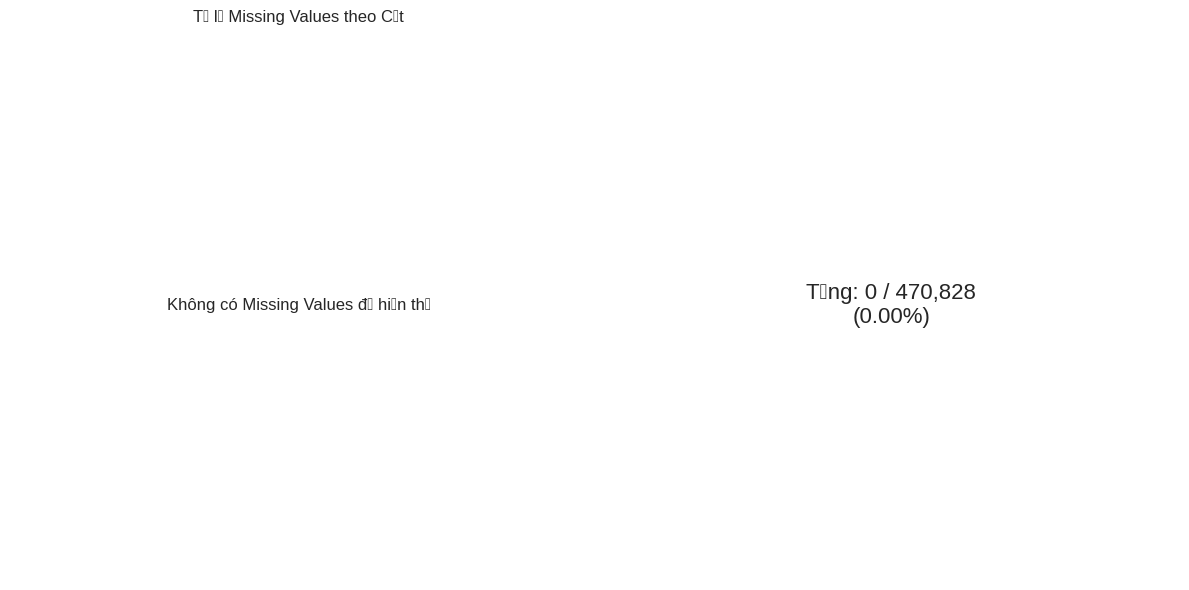

In [24]:
# Phân tích missing values
print("="*70)
print("PHÂN TÍCH MISSING VALUES (GIẢI TRỊ THIẾU)")
print("="*70)

missing_stats = pd.DataFrame({
    'Cột': df.columns,
    'Kiểu': df.dtypes.values,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Non-Null Count': df.count().values
}).sort_values('Missing %', ascending=False)

print("\n" + missing_stats.to_string(index=False))

# Tóm tắt
total_missing = df.isnull().sum().sum()
total_cells = len(df) * len(df.columns)
missing_percent = total_missing / total_cells * 100

print(f"\n📊 Tóm tắt:")
print(f"   • Tổng missing cells: {total_missing:,} / {total_cells:,}")
print(f"   • Tỷ lệ missing: {missing_percent:.2f}%")

# Visualize
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# Check if there are any missing values to plot
if not missing_stats[missing_stats['Missing %'] > 0].empty:
    missing_stats[missing_stats['Missing %'] > 0].plot(x='Cột', y='Missing %', kind='barh', color='coral', ax=plt.gca())
    plt.title('Tỷ lệ Missing Values theo Cột')
    plt.xlabel('Missing %')
else:
    plt.text(0.5, 0.5, 'Không có Missing Values để hiển thị', ha='center', va='center', fontsize=12)
    plt.title('Tỷ lệ Missing Values theo Cột')
    plt.axis('off')

plt.subplot(1, 2, 2)
plt.text(0.5, 0.5, f'Tổng: {total_missing:,} / {total_cells:,}\n({missing_percent:.2f}%)',
         ha='center', va='center', fontsize=16, transform=plt.gca().transAxes)
plt.axis('off')
plt.tight_layout()
plt.show()

## BLOCK 6: Phân tích dữ liệu - Duplicates (Trùng lặp)

In [25]:
print("="*70)
print("PHÂN TÍCH DUPLICATES (DỮ LIỆU TRÙNG LẶP)")
print("="*70)

# Kiểm tra trùng lặp toàn bộ dòng
total_duplicates = df.duplicated().sum()
print(f"\n📊 Dòng trùng lặp toàn bộ: {total_duplicates}")

if total_duplicates > 0:
    print(f"\n❌ Cảnh báo: Phát hiện {total_duplicates} dòng trùng lặp!")
    print(f"\n📋 Ví dụ dòng trùng lặp (hiển thị 10 dòng đầu):")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    print(duplicates_df.head(10))
else:
    print(f"\n✓ Không phát hiện dòng trùng lặp")

# Kiểm tra trùng lặp từng cột
print(f"\n📊 Trùng lặp theo từng cột:")
print("-" * 70)
for col in df.columns:
    unique_count = df[col].nunique()
    total_count = len(df[col].dropna())
    duplicate_percent = (1 - unique_count / total_count) * 100 if total_count > 0 else 0
    print(f"   {col:20s}: {unique_count:6,} unique / {total_count:6,} total ({duplicate_percent:5.2f}% duplicate)")

PHÂN TÍCH DUPLICATES (DỮ LIỆU TRÙNG LẶP)

📊 Dòng trùng lặp toàn bộ: 0

✓ Không phát hiện dòng trùng lặp

📊 Trùng lặp theo từng cột:
----------------------------------------------------------------------
   match_id            :    380 unique / 15,188 total (97.50% duplicate)
   match_date          :    109 unique / 15,188 total (99.28% duplicate)
   season              :      1 unique / 15,188 total (99.99% duplicate)
   home_team           :     20 unique / 15,188 total (99.87% duplicate)
   away_team           :     20 unique / 15,188 total (99.87% duplicate)
   home_score          :      7 unique / 15,188 total (99.95% duplicate)
   away_score          :      7 unique / 15,188 total (99.95% duplicate)
   player_id           :    685 unique / 15,188 total (95.49% duplicate)
   name                :    685 unique / 15,188 total (95.49% duplicate)
   team                :     20 unique / 15,188 total (99.87% duplicate)
   is_home             :      2 unique / 15,188 total (99.99% dupli

## BLOCK 7: Định nghĩa các hàm làm sạch dữ liệu

In [26]:
print("="*70)
print("ĐỊNH NGHĨA CÁC HÀM LÀM SẠCH DỮ LIỆU")
print("="*70)

def clean_text(text):
    """
    Làm sạch dữ liệu text:
    - Loại bỏ khoảng trắng dư thừa
    - Xóa ký tự đặc biệt
    - Chuẩn hóa định dạng
    """
    if pd.isna(text):
        return None

    text = str(text).strip()
    # Loại bỏ khoảng trắng dư thừa
    text = ' '.join(text.split())
    # Loại bỏ ký tự đặc biệt nếu cần (tuỳ chỉnh)
    # text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    return text if text else None

def clean_numeric(value):
    """
    Làm sạch dữ liệu số:
    - Loại bỏ ký tự không phải số
    - Chuyển đổi thành float
    """
    if pd.isna(value):
        return None

    try:
        # Loại bỏ ký tự không phải số (giữ lại dấu âm, dấu chấm, khoảng cách)
        cleaned = str(value).strip()
        cleaned = re.sub(r'[^0-9.-]', '', cleaned)

        if cleaned and cleaned != '.' and cleaned != '-':
            return float(cleaned)
        else:
            return None
    except:
        return None

def clean_date(date_value):
    """
    Làm sạch dữ liệu ngày tháng:
    - Chuẩn hóa format
    - Xử lý các định dạng khác nhau
    """
    if pd.isna(date_value):
        return None

    try:
        if isinstance(date_value, str):
            # Thử các định dạng ngày tháng phổ biến
            date_formats = ["%d/%m/%Y", "%Y-%m-%d", "%d-%m-%Y", "%d.%m.%Y", "%Y/%m/%d"]

            for fmt in date_formats:
                try:
                    return pd.to_datetime(date_value, format=fmt)
                except:
                    continue

            # Nếu không khớp format nào, để pandas tự nhận diện
            return pd.to_datetime(date_value)
        else:
            return pd.to_datetime(date_value)
    except:
        return None

def remove_outliers_iqr(series):
    """
    Phát hiện outliers sử dụng Interquartile Range (IQR)
    Trả về mask boolean để xác định outliers
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return (series >= lower_bound) & (series <= upper_bound)

print("\n✓ Các hàm sau đã được định nghĩa:")
print("   • clean_text() - Làm sạch text")
print("   • clean_numeric() - Làm sạch số")
print("   • clean_date() - Làm sạch ngày tháng")
print("   • remove_outliers_iqr() - Phát hiện outliers")

ĐỊNH NGHĨA CÁC HÀM LÀM SẠCH DỮ LIỆU

✓ Các hàm sau đã được định nghĩa:
   • clean_text() - Làm sạch text
   • clean_numeric() - Làm sạch số
   • clean_date() - Làm sạch ngày tháng
   • remove_outliers_iqr() - Phát hiện outliers


## BLOCK 8: Áp dụng làm sạch dữ liệu

In [27]:
print("="*70)
print("ÁP DỤNG LÀM SẠCH DỮ LIỆU")
print("="*70)

# Tạo bản sao để làm sạch
df_clean = df.copy()

print(f"\n1️⃣ LÀM SẠCH CỘT TEXT")
print("-" * 70)
text_columns = [col for col in df_clean.columns if df_clean[col].dtype == 'object']
print(f"Các cột text: {text_columns}")

for col in text_columns:
    before_nulls = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].apply(clean_text)
    after_nulls = df_clean[col].isnull().sum()
    print(f"   • {col}: {before_nulls} -> {after_nulls} missing values")

print(f"\n2️⃣ LOẠI BỎ DÒNG TRÙNG LẶP")
print("-" * 70)
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_dedup = len(df_clean)
removed = before_dedup - after_dedup
print(f"   • Trước: {before_dedup:,} dòng")
print(f"   • Sau: {after_dedup:,} dòng")
print(f"   • Xóa: {removed:,} dòng ({removed/before_dedup*100:.2f}%)")

print(f"\n3️⃣ RESET INDEX")
print("-" * 70)
df_clean.reset_index(drop=True, inplace=True)
print(f"   ✓ Index đã được reset")

print(f"\n" + "="*70)
print("📊 TÓM TẮT KẾT QUẢ LÀM SẠCH")
print("="*70)
print(f"\nTrước làm sạch:")
print(f"   • Số dòng: {len(df):,}")
print(f"   • Số cột: {len(df.columns)}")
print(f"\nSau làm sạch:")
print(f"   • Số dòng: {len(df_clean):,}")
print(f"   • Số cột: {len(df_clean.columns)}")
print(f"   • Dòng được xóa: {len(df) - len(df_clean):,}")

ÁP DỤNG LÀM SẠCH DỮ LIỆU

1️⃣ LÀM SẠCH CỘT TEXT
----------------------------------------------------------------------
Các cột text: ['match_date', 'season', 'home_team', 'away_team', 'name', 'team', 'position']
   • match_date: 0 -> 0 missing values
   • season: 0 -> 0 missing values
   • home_team: 0 -> 0 missing values
   • away_team: 0 -> 0 missing values
   • name: 0 -> 0 missing values
   • team: 0 -> 0 missing values
   • position: 0 -> 0 missing values

2️⃣ LOẠI BỎ DÒNG TRÙNG LẶP
----------------------------------------------------------------------
   • Trước: 15,188 dòng
   • Sau: 15,188 dòng
   • Xóa: 0 dòng (0.00%)

3️⃣ RESET INDEX
----------------------------------------------------------------------
   ✓ Index đã được reset

📊 TÓM TẮT KẾT QUẢ LÀM SẠCH

Trước làm sạch:
   • Số dòng: 15,188
   • Số cột: 31

Sau làm sạch:
   • Số dòng: 15,188
   • Số cột: 31
   • Dòng được xóa: 0


## BLOCK 9: Xử lý Missing Values

In [28]:
print("="*70)
print("XỬ LÝ MISSING VALUES")
print("="*70)

# ========== CHỌN MỘT TRONG CÁC CHIẾN LƯỢC SAU ==========

# CHIẾN LƯỢC 1: Loại bỏ dòng có bất kỳ missing value nào
# Phù hợp: khi dữ liệu đầy đủ là yêu cầu bắt buộc
print("\n🔹 CHIẾN LƯỢC 1: Loại bỏ dòng có missing values")
print("-" * 70)
df_strategy1 = df_clean.dropna()
print(f"   • Dòng trước: {len(df_clean):,}")
print(f"   • Dòng sau: {len(df_strategy1):,}")
print(f"   • Dòng xóa: {len(df_clean) - len(df_strategy1):,}")

# CHIẾN LƯỢC 2: Điền missing values bằng trung bình (cho cột số)
# Phù hợp: khi muốn giữ lại dòng nhưng điền giá trị số
print("\n🔹 CHIẾN LƯỢC 2: Điền missing bằng trung bình (số)")
print("-" * 70)
df_strategy2 = df_clean.copy()
numeric_cols = df_strategy2.select_dtypes(include=[np.number]).columns
print(f"   • Cột số: {list(numeric_cols)}")
for col in numeric_cols:
    before = df_strategy2[col].isnull().sum()
    df_strategy2[col].fillna(df_strategy2[col].mean(), inplace=True)
    after = df_strategy2[col].isnull().sum()
    print(f"   • {col}: điền {before} giá trị")

# CHIẾN LƯỢC 3: Điền missing values bằng 'Unknown' (cho cột text)
# Phù hợp: khi muốn đánh dấu dữ liệu thiếu với giá trị đặc biệt
print("\n🔹 CHIẾN LƯỢC 3: Điền missing bằng 'Unknown' (text)")
print("-" * 70)
df_strategy3 = df_clean.copy()
text_cols = df_strategy3.select_dtypes(include=['object']).columns
print(f"   • Cột text: {list(text_cols)}")
for col in text_cols:
    before = df_strategy3[col].isnull().sum()
    df_strategy3[col].fillna('Unknown', inplace=True)
    after = df_strategy3[col].isnull().sum()
    print(f"   • {col}: điền {before} giá trị")

# CHIẾN LƯỢC 4: Loại bỏ cột có quá nhiều missing values
# Phù hợp: khi cột có quá nhiều dữ liệu thiếu (không đáng tin cậy)
print("\n🔹 CHIẾN LƯỢC 4: Loại bỏ cột có quá nhiều missing")
print("-" * 70)
threshold = 0.5  # Nếu > 50% missing, loại bỏ
df_strategy4 = df_clean.copy()
cols_before = len(df_strategy4.columns)
cols_to_drop = [col for col in df_strategy4.columns
                 if df_strategy4[col].isnull().sum() / len(df_strategy4) > threshold]
print(f"   • Threshold: {threshold*100:.0f}%")
print(f"   • Cột cần xóa: {cols_to_drop}")
df_strategy4 = df_strategy4.drop(columns=cols_to_drop)
print(f"   • Cột trước: {cols_before}")
print(f"   • Cột sau: {len(df_strategy4)}")

# ========== CHỌN CHIẾN LƯỢC CUỐI CÙNG ==========
print("\n" + "="*70)
print("💡 CHỌN CHIẾN LƯỢC CUỐI CÙNG")
print("="*70)
print("\nChọn một trong các chiến lược trên:")
print("  1 = Loại bỏ dòng có missing")
print("  2 = Điền trung bình (số) + Unknown (text)")
print("  3 = Chỉ điền 'Unknown' cho text")
print("  4 = Loại bỏ cột có quá nhiều missing")

# Mặc định: Chiến lược 2 (kết hợp)
strategy = 2
print(f"\n➜ Sử dụng chiến lược {strategy}")

if strategy == 1:
    df_clean = df_strategy1
elif strategy == 2:
    df_clean = df_strategy2.copy()
    text_cols = df_clean.select_dtypes(include=['object']).columns
    for col in text_cols:
        df_clean[col].fillna('Unknown', inplace=True)
elif strategy == 3:
    df_clean = df_strategy3
elif strategy == 4:
    df_clean = df_strategy4

print(f"\n✓ Áp dụng chiến lược {strategy} thành công!")
print(f"\nMissing values còn lại:")
print(df_clean.isnull().sum())

XỬ LÝ MISSING VALUES

🔹 CHIẾN LƯỢC 1: Loại bỏ dòng có missing values
----------------------------------------------------------------------
   • Dòng trước: 15,188
   • Dòng sau: 15,188
   • Dòng xóa: 0

🔹 CHIẾN LƯỢC 2: Điền missing bằng trung bình (số)
----------------------------------------------------------------------
   • Cột số: ['match_id', 'home_score', 'away_score', 'player_id', 'is_home', 'is_first_eleven', 'is_man_of_match', 'age', 'minutes_played', 'rating', 'goals', 'assists', 'shots_total', 'shots_on_target', 'key_passes', 'passes_completed', 'passes_total', 'pass_accuracy', 'tackles', 'interceptions', 'clearances', 'aerial_won', 'dribbles_won', 'fouls_committed']
   • match_id: điền 0 giá trị
   • home_score: điền 0 giá trị
   • away_score: điền 0 giá trị
   • player_id: điền 0 giá trị
   • is_home: điền 0 giá trị
   • is_first_eleven: điền 0 giá trị
   • is_man_of_match: điền 0 giá trị
   • age: điền 0 giá trị
   • minutes_played: điền 0 giá trị
   • rating: điền 0 giá

## BLOCK 10: Kiểm tra và làm sạch cột số

In [29]:
print("="*70)
print("KIỂM TRA VÀ LÀM SẠCH CỘT SỐ")
print("="*70)

# Xác định cột số
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"\nCác cột số được phát hiện: {numeric_cols}")

    for col in numeric_cols:
        print(f"\n📊 Cột: {col}")
        print("-" * 70)
        print(f"   • Kiểu: {df_clean[col].dtype}")
        print(f"   • Null: {df_clean[col].isnull().sum()}")
        print(f"   • Min: {df_clean[col].min():.4f}")
        print(f"   • Max: {df_clean[col].max():.4f}")
        print(f"   • Mean: {df_clean[col].mean():.4f}")
        print(f"   • Median: {df_clean[col].median():.4f}")
        print(f"   • Std: {df_clean[col].std():.4f}")
else:
    print("\n⚠️ Không có cột số")

KIỂM TRA VÀ LÀM SẠCH CỘT SỐ

Các cột số được phát hiện: ['match_id', 'home_score', 'away_score', 'player_id', 'is_home', 'is_first_eleven', 'is_man_of_match', 'age', 'minutes_played', 'rating', 'goals', 'assists', 'shots_total', 'shots_on_target', 'key_passes', 'passes_completed', 'passes_total', 'pass_accuracy', 'tackles', 'interceptions', 'clearances', 'aerial_won', 'dribbles_won', 'fouls_committed']

📊 Cột: match_id
----------------------------------------------------------------------
   • Kiểu: int64
   • Null: 0
   • Min: 1821049.0000
   • Max: 1821428.0000
   • Mean: 1821238.5024
   • Median: 1821239.0000
   • Std: 109.6994

📊 Cột: home_score
----------------------------------------------------------------------
   • Kiểu: int64
   • Null: 0
   • Min: 0.0000
   • Max: 7.0000
   • Mean: 1.5133
   • Median: 1.0000
   • Std: 1.2765

📊 Cột: away_score
----------------------------------------------------------------------
   • Kiểu: int64
   • Null: 0
   • Min: 0.0000
   • Max: 6.000

## BLOCK 11: Phát hiện Outliers

PHÁT HIỆN OUTLIERS (GIÁ TRỊ NGOẠI LỆ)

📊 Cột: match_id
----------------------------------------------------------------------
   • Q1 (25%): 1821143.7500
   • Q3 (75%): 1821334.0000
   • IQR: 190.2500
   • Khoảng bình thường: [1820858.3750, 1821619.3750]
   • Số outliers: 0 (0.00%)

📊 Cột: home_score
----------------------------------------------------------------------
   • Q1 (25%): 1.0000
   • Q3 (75%): 2.0000
   • IQR: 1.0000
   • Khoảng bình thường: [-0.5000, 3.5000]
   • Số outliers: 1320 (8.69%)
   • Giá trị outliers: [np.int64(4), np.int64(5), np.int64(7)]

📊 Cột: away_score
----------------------------------------------------------------------
   • Q1 (25%): 1.0000
   • Q3 (75%): 2.0000
   • IQR: 1.0000
   • Khoảng bình thường: [-0.5000, 3.5000]
   • Số outliers: 840 (5.53%)
   • Giá trị outliers: [np.int64(4), np.int64(5), np.int64(6)]

📊 Cột: player_id
----------------------------------------------------------------------
   • Q1 (25%): 143595.0000
   • Q3 (75%): 401254.0000

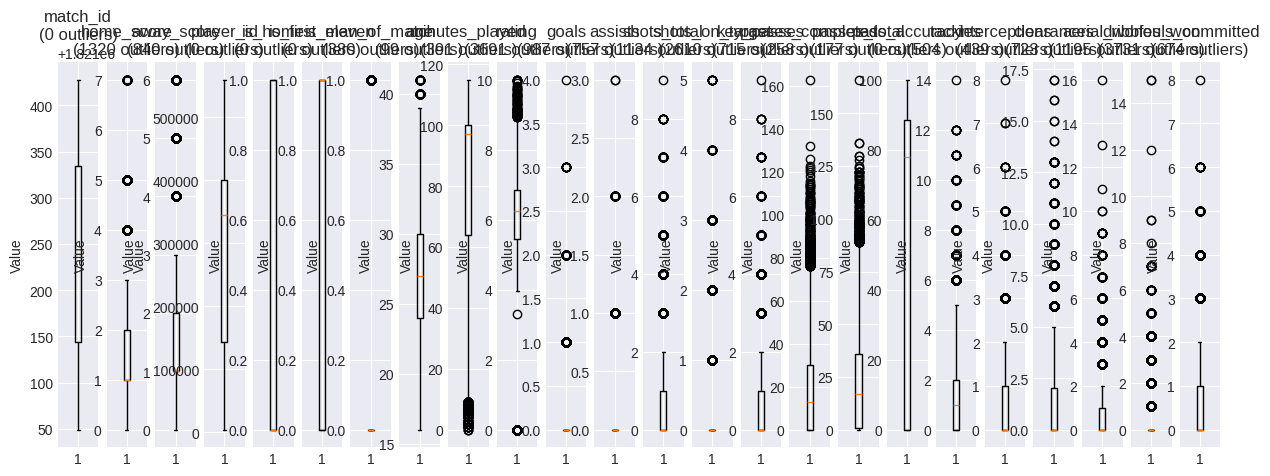


💡 Lưu ý: Chọn xóa outliers nếu bạn chắc chắn chúng là lỗi dữ liệu
   Để xóa outliers, hãy chạy code ở block tiếp theo


In [30]:
print("="*70)
print("PHÁT HIỆN OUTLIERS (GIÁ TRỊ NGOẠI LỆ)")
print("="*70)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    outliers_summary = {}

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        num_outliers = outliers_mask.sum()
        outliers_summary[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower': lower_bound,
            'upper': upper_bound,
            'count': num_outliers,
            'percent': num_outliers / len(df_clean) * 100
        }

        print(f"\n📊 Cột: {col}")
        print("-" * 70)
        print(f"   • Q1 (25%): {Q1:.4f}")
        print(f"   • Q3 (75%): {Q3:.4f}")
        print(f"   • IQR: {IQR:.4f}")
        print(f"   • Khoảng bình thường: [{lower_bound:.4f}, {upper_bound:.4f}]")
        print(f"   • Số outliers: {num_outliers} ({outliers_summary[col]['percent']:.2f}%)")

        if num_outliers > 0:
            print(f"   • Giá trị outliers: {sorted(df_clean[col][outliers_mask].unique())}")

    # Visualize
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))
    if len(numeric_cols) == 1:
        axes = [axes]

    for idx, col in enumerate(numeric_cols):
        axes[idx].boxplot(df_clean[col].dropna())
        axes[idx].set_title(f'{col}\n({outliers_summary[col]["count"]} outliers)')
        axes[idx].set_ylabel('Value')

    plt.tight_layout()
    plt.show()

    print("\n💡 Lưu ý: Chọn xóa outliers nếu bạn chắc chắn chúng là lỗi dữ liệu")
    print("   Để xóa outliers, hãy chạy code ở block tiếp theo")
else:
    print("\n⚠️ Không có cột số để phát hiện outliers")

## BLOCK 12: (Tuỳ chọn) Xóa Outliers

In [31]:
print("="*70)
print("XÓA OUTLIERS (TỰY CHỌN)")
print("="*70)

# ========== CẤU HÌNH XÓA OUTLIERS ==========
REMOVE_OUTLIERS = False  # Đặt True để xóa, False để giữ
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n⚙️ Cấu hình: REMOVE_OUTLIERS = {REMOVE_OUTLIERS}")

if REMOVE_OUTLIERS and numeric_cols:
    before_rows = len(df_clean)

    for col in numeric_cols:
        mask = remove_outliers_iqr(df_clean[col])
        df_clean = df_clean[mask]

    after_rows = len(df_clean)
    removed_rows = before_rows - after_rows

    print(f"\n✓ Dòng trước: {before_rows:,}")
    print(f"✓ Dòng sau: {after_rows:,}")
    print(f"✓ Dòng xóa: {removed_rows:,} ({removed_rows/before_rows*100:.2f}%)")

    df_clean.reset_index(drop=True, inplace=True)
elif REMOVE_OUTLIERS:
    print("\n⚠️ Không có cột số, không thể xóa outliers")
else:
    print("\n✓ Giữ lại outliers (REMOVE_OUTLIERS = False)")

XÓA OUTLIERS (TỰY CHỌN)

⚙️ Cấu hình: REMOVE_OUTLIERS = False

✓ Giữ lại outliers (REMOVE_OUTLIERS = False)


## BLOCK 13: Chuẩn hóa dữ liệu (Normalization)

CHUẨN HÓA DỮ LIỆU (NORMALIZATION)

Các cột sẽ được chuẩn hóa: ['match_id', 'home_score', 'away_score', 'player_id', 'is_home', 'is_first_eleven', 'is_man_of_match', 'age', 'minutes_played', 'rating', 'goals', 'assists', 'shots_total', 'shots_on_target', 'key_passes', 'passes_completed', 'passes_total', 'pass_accuracy', 'tackles', 'interceptions', 'clearances', 'aerial_won', 'dribbles_won', 'fouls_committed']

🔹 MIN-MAX SCALING (Range: [0, 1])
----------------------------------------------------------------------
   • Công thức: (x - min) / (max - min)
   • Phạm vi: [0, 1]

   Thống kê sau Min-Max Scaling:
           match_id    home_score    away_score     player_id       is_home  \
count  15188.000000  15188.000000  15188.000000  15188.000000  15188.000000   
mean       0.500006      0.216186      0.236865      0.543607      0.499934   
std        0.289444      0.182364      0.198113      0.241864      0.500016   
min        0.000000      0.000000      0.000000      0.000000      0.00

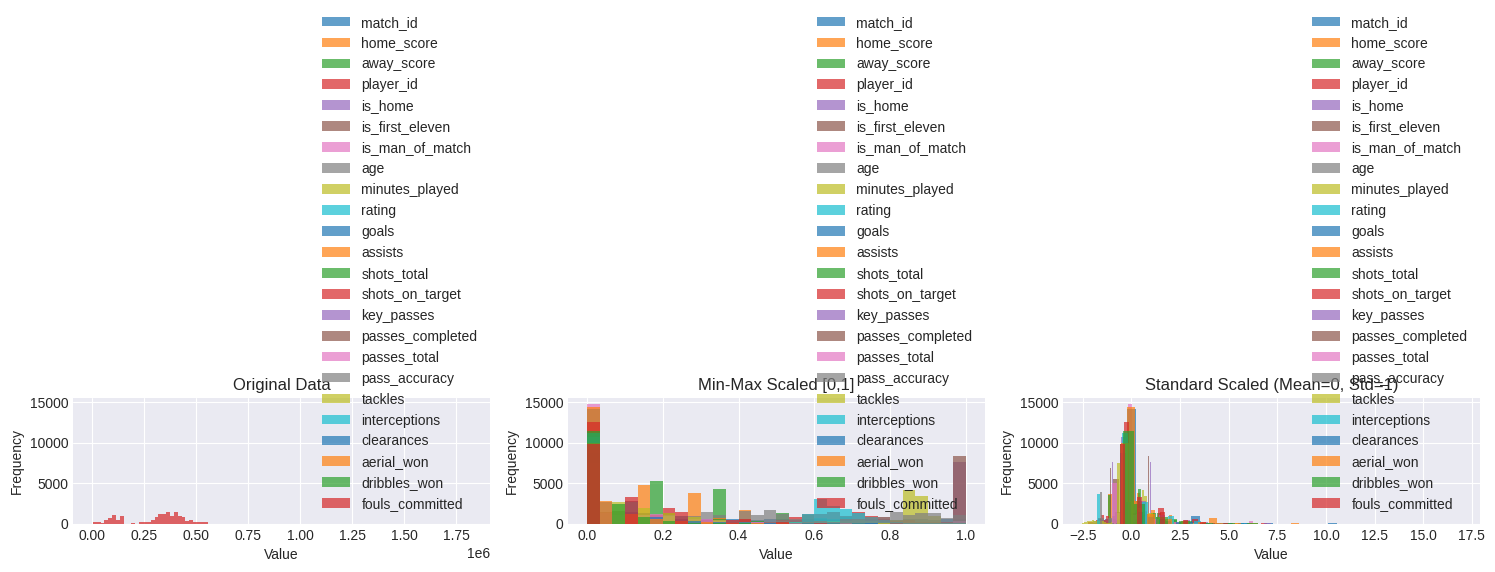


💡 Chọn chuẩn hóa:
   • Min-Max: Khi cần giữ ngữ cảnh của dữ liệu (VD: Neural Networks)
   • Standard: Khi dữ liệu theo phân phối chuẩn (VD: Linear Regression)


In [32]:
print("="*70)
print("CHUẨN HÓA DỮ LIỆU (NORMALIZATION)")
print("="*70)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"\nCác cột sẽ được chuẩn hóa: {numeric_cols}")

    # ========== MIN-MAX SCALING ==========
    print(f"\n🔹 MIN-MAX SCALING (Range: [0, 1])")
    print("-" * 70)

    scaler_minmax = MinMaxScaler(feature_range=(0, 1))
    df_minmax = df_clean.copy()
    df_minmax[numeric_cols] = scaler_minmax.fit_transform(df_clean[numeric_cols])

    print(f"   • Công thức: (x - min) / (max - min)")
    print(f"   • Phạm vi: [0, 1]")
    print(f"\n   Thống kê sau Min-Max Scaling:")
    print(df_minmax[numeric_cols].describe())

    # ========== STANDARD SCALING ==========
    print(f"\n🔹 STANDARD SCALING (Standardization)")
    print("-" * 70)

    scaler_std = StandardScaler()
    df_standardized = df_clean.copy()
    df_standardized[numeric_cols] = scaler_std.fit_transform(df_clean[numeric_cols])

    print(f"   • Công thức: (x - mean) / std")
    print(f"   • Mean: 0, Std: 1")
    print(f"\n   Thống kê sau Standard Scaling:")
    print(df_standardized[numeric_cols].describe())

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Original
    for col in numeric_cols:
        axes[0].hist(df_clean[col].dropna(), alpha=0.7, label=col, bins=30)
    axes[0].set_title('Original Data')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    # Min-Max
    for col in numeric_cols:
        axes[1].hist(df_minmax[col].dropna(), alpha=0.7, label=col, bins=30)
    axes[1].set_title('Min-Max Scaled [0,1]')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()

    # Standard
    for col in numeric_cols:
        axes[2].hist(df_standardized[col].dropna(), alpha=0.7, label=col, bins=30)
    axes[2].set_title('Standard Scaled (Mean=0, Std=1)')
    axes[2].set_xlabel('Value')
    axes[2].set_ylabel('Frequency')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"\n💡 Chọn chuẩn hóa:")
    print(f"   • Min-Max: Khi cần giữ ngữ cảnh của dữ liệu (VD: Neural Networks)")
    print(f"   • Standard: Khi dữ liệu theo phân phối chuẩn (VD: Linear Regression)")
else:
    print("\n⚠️ Không có cột số để chuẩn hóa")
    df_minmax = df_clean
    df_standardized = df_clean

## BLOCK 14: Chọn phiên bản cuối cùng

In [33]:
print("="*70)
print("CHỌN PHIÊN BẢN CUỐI CÙNG")
print("="*70)

print(f"\n📌 Có 3 phiên bản dữ liệu sẵn sàng:")
print(f"   1. df_clean - Dữ liệu đã làm sạch (gốc)")
print(f"   2. df_minmax - Dữ liệu đã chuẩn hóa Min-Max [0,1]")
print(f"   3. df_standardized - Dữ liệu đã chuẩn hóa Standard (mean=0, std=1)")

# ========== CẤU HÌNH CHỌN PHIÊN BẢN ==========
VERSION = 'clean'  # Chọn: 'clean', 'minmax', 'standard'

print(f"\n➜ Phiên bản được chọn: {VERSION}")

if VERSION == 'clean':
    df_final = df_clean
elif VERSION == 'minmax':
    df_final = df_minmax
elif VERSION == 'standard':
    df_final = df_standardized
else:
    print("⚠️ Phiên bản không hợp lệ, sử dụng df_clean")
    df_final = df_clean

print(f"\n✓ Dữ liệu cuối cùng:")
print(f"   • Số dòng: {len(df_final):,}")
print(f"   • Số cột: {len(df_final.columns)}")
print(f"\n   Dữ liệu mẫu:")
print(df_final.head())

CHỌN PHIÊN BẢN CUỐI CÙNG

📌 Có 3 phiên bản dữ liệu sẵn sàng:
   1. df_clean - Dữ liệu đã làm sạch (gốc)
   2. df_minmax - Dữ liệu đã chuẩn hóa Min-Max [0,1]
   3. df_standardized - Dữ liệu đã chuẩn hóa Standard (mean=0, std=1)

➜ Phiên bản được chọn: clean

✓ Dữ liệu cuối cùng:
   • Số dòng: 15,188
   • Số cột: 31

   Dữ liệu mẫu:
   match_id  match_date     season  home_team away_team  home_score  \
0   1821420  2025-02-15  2024/2025  Leicester   Arsenal           0   
1   1821420  2025-02-15  2024/2025  Leicester   Arsenal           0   
2   1821420  2025-02-15  2024/2025  Leicester   Arsenal           0   
3   1821420  2025-02-15  2024/2025  Leicester   Arsenal           0   
4   1821420  2025-02-15  2024/2025  Leicester   Arsenal           0   

   away_score  player_id                name       team  is_home position  \
0           2     409426      Mads Hermansen  Leicester        1       GK   
1           2     301441        James Justin  Leicester        1       DR   
2        

## BLOCK 15: Lưu dữ liệu đã xử lý

In [34]:
print("="*70)
print("LƯU DỮ LIỆU ĐÃ XỬ LÝ")
print("="*70)

# ========== LƯU CÁC PHIÊN BẢN ==========

# 1. Lưu dữ liệu đã làm sạch (gốc)
print(f"\n1️⃣ Lưu dữ liệu đã làm sạch...")
try:
    df_clean.to_excel(output_clean, index=False)
    print(f"   ✓ {output_clean}")
    df_clean.to_csv(output_clean_csv, index=False, encoding='utf-8-sig')
    print(f"   ✓ {output_clean_csv}")
except Exception as e:
    print(f"   ❌ Lỗi: {e}")

# 2. Lưu dữ liệu đã chuẩn hóa Min-Max
print(f"\n2️⃣ Lưu dữ liệu đã chuẩn hóa Min-Max...")
try:
    output_minmax = output_normalized.replace('.xlsx', '_minmax.xlsx')
    df_minmax.to_excel(output_minmax, index=False)
    print(f"   ✓ {output_minmax}")
except Exception as e:
    print(f"   ❌ Lỗi: {e}")

# 3. Lưu dữ liệu đã chuẩn hóa Standard
print(f"\n3️⃣ Lưu dữ liệu đã chuẩn hóa Standard...")
try:
    output_standard = output_normalized.replace('.xlsx', '_standard.xlsx')
    df_standardized.to_excel(output_standard, index=False)
    print(f"   ✓ {output_standard}")
except Exception as e:
    print(f"   ❌ Lỗi: {e}")

# 4. Lưu báo cáo metadata
print(f"\n4️⃣ Lưu báo cáo metadata...")
try:
    metadata = pd.DataFrame({
        'Thông Tin': [
            'Dữ liệu gốc (dòng)',
            'Dữ liệu gốc (cột)',
            'Dữ liệu sạch (dòng)',
            'Dữ liệu sạch (cột)',
            'Dòng xóa',
            'Cột xóa',
            'Ngày xử lý'
        ],
        'Giá Trị': [
            len(df_original),
            len(df_original.columns),
            len(df_clean),
            len(df_clean.columns),
            len(df_original) - len(df_clean),
            len(df_original.columns) - len(df_clean.columns),
            datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        ]
    })
    output_metadata = output_clean.replace('.xlsx', '_metadata.xlsx')
    metadata.to_excel(output_metadata, index=False)
    print(f"   ✓ {output_metadata}")
except Exception as e:
    print(f"   ❌ Lỗi: {e}")

print(f"\n" + "="*70)
print(f"✓ Tất cả file đã được lưu thành công!")
print(f"="*70)

LƯU DỮ LIỆU ĐÃ XỬ LÝ

1️⃣ Lưu dữ liệu đã làm sạch...
   ✓ /content/drive/MyDrive/Pl_MOTM/PlayerCrawl_cleaned.xlsx
   ✓ /content/drive/MyDrive/Pl_MOTM/PlayerCrawl_cleaned.csv

2️⃣ Lưu dữ liệu đã chuẩn hóa Min-Max...
   ✓ /content/drive/MyDrive/Pl_MOTM/PlayerCrawl_normalized_minmax.xlsx

3️⃣ Lưu dữ liệu đã chuẩn hóa Standard...
   ✓ /content/drive/MyDrive/Pl_MOTM/PlayerCrawl_normalized_standard.xlsx

4️⃣ Lưu báo cáo metadata...
   ✓ /content/drive/MyDrive/Pl_MOTM/PlayerCrawl_cleaned_metadata.xlsx

✓ Tất cả file đã được lưu thành công!


## BLOCK 16: Báo cáo tóm tắt cuối cùng

In [ ]:
print("\n" + "="*70)
print("📋 BÁO CÁO TÓM TẮT CUỐI CÙNG")
print("="*70)

print(f"\n1️⃣ THÔNG TIN TỔNG QUÁT:")
print("-" * 70)
print(f"   • Dữ liệu gốc: {len(df_original):,} dòng × {len(df_original.columns)} cột")
print(f"   • Dữ liệu sạch: {len(df_clean):,} dòng × {len(df_clean.columns)} cột")
print(f"   • Dòng bị xóa: {len(df_original) - len(df_clean):,} ({(len(df_original) - len(df_clean))/len(df_original)*100:.2f}%)")
print(f"   • Cột bị xóa: {len(df_original.columns) - len(df_clean.columns)}")

print(f"\n2️⃣ CÁC BƯỚC XỬ LÝ:")
print("-" * 70)
print(f"   ✓ Loại bỏ khoảng trắng dư thừa (text)")
print(f"   ✓ Loại bỏ dòng trùng lặp")
print(f"   ✓ Xử lý missing values")
print(f"   ✓ Phát hiện outliers (IQR method)")
if REMOVE_OUTLIERS:
    print(f"   ✓ Xóa outliers")
else:
    print(f"   • Giữ lại outliers")
print(f"   ✓ Chuẩn hóa dữ liệu")

print(f"\n3️⃣ KIỂU DỮ LIỆU:")
print("-" * 70)
dtype_counts = df_clean.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   • {dtype}: {count}")

print(f"\n4️⃣ THỐNG KÊ MISSING VALUES:")
print("-" * 70)
total_missing = df_clean.isnull().sum().sum()
total_cells = len(df_clean) * len(df_clean.columns)
print(f"   • Missing cells: {total_missing:,} / {total_cells:,}")
print(f"   • Tỷ lệ missing: {total_missing/total_cells*100:.4f}%")

print(f"\n5️⃣ FILE ĐẦU RA:")
print("-" * 70)
print(f"   📄 {output_clean}")
print(f"   📄 {output_clean_csv}")
print(f"   📄 {output_minmax}")
print(f"   📄 {output_standard}")
print(f"   📄 {output_metadata}")

print(f"\n6️⃣ ĐỐI TƯỢNG DỮ LIỆU MẪU (5 DÒNG ĐẦU):")
print("-" * 70)
print(df_clean.head())

print(f"\n7️⃣ ĐỐI TƯỢNG DỰA LIỆU MẪU (5 DÒNG CUỐI):")
print("-" * 70)
print(df_clean.tail())

print(f"\n" + "="*70)
print(f"✅ HOÀN THÀNH! Quá trình làm sạch và chuẩn hóa dữ liệu thành công!")
print(f"="*70)
print(f"\n🎉 Dữ liệu đã sẵn sàng cho giai đoạn tiếp theo (EDA, Modeling)")

In [1]:
{
 "cells": [
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "# Data Cleaning and Normalization for MOTM Prediction\n",
    "## Làm sạch và chuẩn hóa dữ liệu cho dự đoán MOTM\n",
    "\n",
    "Notebook này hướng dẫn chi tiết cách làm sạch và chuẩn hóa dữ liệu cho dự án dự đoán Man of The Match"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 1: Cài đặt và Import thư viện"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# Import các thư viện cần thiết\n",
    "import pandas as pd\n",
    "import numpy as np\n",
    "import re\n",
    "import warnings\n",
    "from datetime import datetime\n",
    "from sklearn.preprocessing import MinMaxScaler, StandardScaler\n",
    "import matplotlib.pyplot as plt\n",
    "import seaborn as sns\n",
    "\n",
    "warnings.filterwarnings('ignore')\n",
    "\n",
    "# Cấu hình hiển thị\n",
    "pd.set_option('display.max_columns', None)\n",
    "pd.set_option('display.max_rows', 100)\n",
    "plt.style.use('seaborn-v0_8-darkgrid')\n",
    "\n",
    "print(\"✓ Tất cả thư viện đã được import thành công!\")\n",
    "print(f\"✓ Pandas version: {pd.__version__}\")\n",
    "print(f\"✓ NumPy version: {np.__version__}\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 2: Mount Google Drive (Nếu dùng Colab)"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# Kiểm tra và mount Google Drive\n",
    "try:\n",
    "    from google.colab import drive\n",
    "    drive.mount('/content/drive')\n",
    "    colab = True\n",
    "    print(\"✓ Google Drive đã được mount thành công!\")\nexcept:\n",
    "    colab = False\n",
    "    print(\"✓ Không phải Google Colab - chạy local\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 3: Cấu hình đường dẫn file"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============ CẤU HÌNH ĐƯỜNG DẪN ============\n",
    "\n",
    "if colab:\n",
    "    # Đối với Google Colab - điều chỉnh path của bạn\n",
    "    base_path = '/content/drive/My Drive/MotmPrediction'\n",
    "    input_file = f'{base_path}/PlayerCrawl.xlsx'\n",
    "    output_clean = f'{base_path}/PlayerCrawl_cleaned.xlsx'\n",
    "    output_normalized = f'{base_path}/PlayerCrawl_normalized.xlsx'\n",
    "    output_clean_csv = f'{base_path}/PlayerCrawl_cleaned.csv'\n",
    "else:\n",
    "    # Đối với chạy local\n",
    "    base_path = '.'\n",
    "    input_file = 'PlayerCrawl.xlsx'\n",
    "    output_clean = 'PlayerCrawl_cleaned.xlsx'\n",
    "    output_normalized = 'PlayerCrawl_normalized.xlsx'\n",
    "    output_clean_csv = 'PlayerCrawl_cleaned.csv'\n",
    "\n",
    "print(f\"📁 Đường dẫn input: {input_file}\")\n",
    "print(f\"📁 Đường dẫn output (clean): {output_clean}\")\n",
    "print(f\"📁 Đường dẫn output (normalized): {output_normalized}\")\n",
    "print(f\"📁 Đường dẫn output (CSV): {output_clean_csv}\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 4: Load dữ liệu gốc"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# Load dữ liệu\n",
    "df = pd.read_excel(input_file)\n",
    "\n",
    "# Lưu bản sao để so sánh sau\n",
    "df_original = df.copy()\n",
    "\n",
    "print(\"=\"*70)\n",
    "print(\"THÔNG TIN TỔNG QUÁT DỮ LIỆU GỐC\")\n",
    "print(\"=\"*70)\n",
    "print(f\"\\n📊 Kích thước dữ liệu:\")\n",
    "print(f\"   • Số dòng: {len(df):,}\")\n",
    "print(f\"   • Số cột: {len(df.columns)}\")\n",
    "print(f\"   • Tổng cells: {len(df) * len(df.columns):,}\")\n",
    "\n",
    "print(f\"\\n📋 Danh sách các cột:\")\n",
    "for i, col in enumerate(df.columns, 1):\n",
    "    print(f\"   {i:2d}. {col}\")\n",
    "\n",
    "print(f\"\\n💾 Kiểu dữ liệu:\")\n",
    "print(df.dtypes)\n",
    "\n",
    "print(f\"\\n📈 Dữ liệu mẫu (5 dòng đầu):\")\n",
    "print(df.head())\n",
    "\n",
    "print(f\"\\n📊 Thống kê mô tả:\")\n",
    "print(df.describe())"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 5: Phân tích dữ liệu - Missing Values"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# Phân tích missing values\n",
    "print(\"=\"*70)\n",
    "print(\"PHÂN TÍCH MISSING VALUES (GIẢI TRỊ THIẾU)\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "missing_stats = pd.DataFrame({\n",
    "    'Cột': df.columns,\n",
    "    'Kiểu': df.dtypes.values,\n",
    "    'Missing Count': df.isnull().sum().values,\n",
    "    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values,\n",
    "    'Non-Null Count': df.count().values\n",
    "}).sort_values('Missing %', ascending=False)\n",
    "\n",
    "print(\"\\n\" + missing_stats.to_string(index=False))\n",
    "\n",
    "# Tóm tắt\n",
    "total_missing = df.isnull().sum().sum()\n",
    "total_cells = len(df) * len(df.columns)\n",
    "missing_percent = total_missing / total_cells * 100\n",
    "\n",
    "print(f\"\\n📊 Tóm tắt:\")\n",
    "print(f\"   • Tổng missing cells: {total_missing:,} / {total_cells:,}\")\n",
    "print(f\"   • Tỷ lệ missing: {missing_percent:.2f}%\")\n",
    "\n",
    "# Visualize\n",
    "plt.figure(figsize=(12, 6))\n",
    "plt.subplot(1, 2, 1)\n",
    "missing_stats[missing_stats['Missing %'] > 0].plot(x='Cột', y='Missing %', kind='barh', color='coral')\n",
    "plt.title('Tỷ lệ Missing Values theo Cột')\n",
    "plt.xlabel('Missing %')\n",
    "\n",
    "plt.subplot(1, 2, 2)\n",
    "plt.text(0.5, 0.5, f'Tổng: {total_missing:,} / {total_cells:,}\\n({missing_percent:.2f}%)', \n",
    "         ha='center', va='center', fontsize=16, transform=plt.gca().transAxes)\n",
    "plt.axis('off')\n",
    "plt.tight_layout()\n",
    "plt.show()"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 6: Phân tích dữ liệu - Duplicates (Trùng lặp)"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"PHÂN TÍCH DUPLICATES (DỮ LIỆU TRÙNG LẶP)\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "# Kiểm tra trùng lặp toàn bộ dòng\n",
    "total_duplicates = df.duplicated().sum()\n",
    "print(f\"\\n📊 Dòng trùng lặp toàn bộ: {total_duplicates}\")\n",
    "\n",
    "if total_duplicates > 0:\n",
    "    print(f\"\\n❌ Cảnh báo: Phát hiện {total_duplicates} dòng trùng lặp!\")\n",
    "    print(f\"\\n📋 Ví dụ dòng trùng lặp (hiển thị 10 dòng đầu):\")\n",
    "    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))\n",
    "    print(duplicates_df.head(10))\nelse:\n",
    "    print(f\"\\n✓ Không phát hiện dòng trùng lặp\")\n",
    "\n",
    "# Kiểm tra trùng lặp từng cột\n",
    "print(f\"\\n📊 Trùng lặp theo từng cột:\")\n",
    "print(\"-\" * 70)\n",
    "for col in df.columns:\n",
    "    unique_count = df[col].nunique()\n",
    "    total_count = len(df[col].dropna())\n",
    "    duplicate_percent = (1 - unique_count / total_count) * 100 if total_count > 0 else 0\n",
    "    print(f\"   {col:20s}: {unique_count:6,} unique / {total_count:6,} total ({duplicate_percent:5.2f}% duplicate)\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 7: Định nghĩa các hàm làm sạch dữ liệu"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"ĐỊNH NGHĨA CÁC HÀM LÀM SẠCH DỮ LIỆU\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "def clean_text(text):\n",
    "    \"\"\"\n",
    "    Làm sạch dữ liệu text:\n",
    "    - Loại bỏ khoảng trắng dư thừa\n",
    "    - Xóa ký tự đặc biệt\n",
    "    - Chuẩn hóa định dạng\n",
    "    \"\"\"\n",
    "    if pd.isna(text):\n",
    "        return None\n",
    "    \n",
    "    text = str(text).strip()\n",
    "    # Loại bỏ khoảng trắng dư thừa\n",
    "    text = ' '.join(text.split())\n",
    "    # Loại bỏ ký tự đặc biệt nếu cần (tuỳ chỉnh)\n",
    "    # text = re.sub(r'[^a-zA-Z0-9\\s]', '', text)\n",
    "    \n",
    "    return text if text else None\n",
    "\n",
    "def clean_numeric(value):\n",
    "    \"\"\"\n",
    "    Làm sạch dữ liệu số:\n",
    "    - Loại bỏ ký tự không phải số\n",
    "    - Chuyển đổi thành float\n",
    "    \"\"\"\n",
    "    if pd.isna(value):\n",
    "        return None\n",
    "    \n",
    "    try:\n",
    "        # Loại bỏ ký tự không phải số (giữ lại dấu âm, dấu chấm, khoảng cách)\n",
    "        cleaned = str(value).strip()\n",
    "        cleaned = re.sub(r'[^0-9.-]', '', cleaned)\n",
    "        \n",
    "        if cleaned and cleaned != '.' and cleaned != '-':\n",
    "            return float(cleaned)\n",
    "        else:\n",
    "            return None\n",
    "    except:\n",
    "        return None\n",
    "\n",
    "def clean_date(date_value):\n",
    "    \"\"\"\n",
    "    Làm sạch dữ liệu ngày tháng:\n",
    "    - Chuẩn hóa format\n",
    "    - Xử lý các định dạng khác nhau\n",
    "    \"\"\"\n",
    "    if pd.isna(date_value):\n",
    "        return None\n",
    "    \n",
    "    try:\n",
    "        if isinstance(date_value, str):\n",
    "            # Thử các định dạng ngày tháng phổ biến\n",
    "            date_formats = [\"%d/%m/%Y\", \"%Y-%m-%d\", \"%d-%m-%Y\", \"%d.%m.%Y\", \"%Y/%m/%d\"]\n",
    "            \n",
    "            for fmt in date_formats:\n",
    "                try:\n",
    "                    return pd.to_datetime(date_value, format=fmt)\n",
    "                except:\n",
    "                    continue\n",
    "            \n",
    "            # Nếu không khớp format nào, để pandas tự nhận diện\n",
    "            return pd.to_datetime(date_value)\n",
    "        else:\n",
    "            return pd.to_datetime(date_value)\n",
    "    except:\n",
    "        return None\n",
    "\n",
    "def remove_outliers_iqr(series):\n",
    "    \"\"\"\n",
    "    Phát hiện outliers sử dụng Interquartile Range (IQR)\n",
    "    Trả về mask boolean để xác định outliers\n",
    "    \"\"\"\n",
    "    Q1 = series.quantile(0.25)\n",
    "    Q3 = series.quantile(0.75)\n",
    "    IQR = Q3 - Q1\n",
    "    \n",
    "    lower_bound = Q1 - 1.5 * IQR\n",
    "    upper_bound = Q3 + 1.5 * IQR\n",
    "    \n",
    "    return (series >= lower_bound) & (series <= upper_bound)\n",
    "\n",
    "print(\"\\n✓ Các hàm sau đã được định nghĩa:\")\n",
    "print(\"   • clean_text() - Làm sạch text\")\n",
    "print(\"   • clean_numeric() - Làm sạch số\")\n",
    "print(\"   • clean_date() - Làm sạch ngày tháng\")\n",
    "print(\"   • remove_outliers_iqr() - Phát hiện outliers\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 8: Áp dụng làm sạch dữ liệu"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"ÁP DỤNG LÀM SẠCH DỮ LIỆU\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "# Tạo bản sao để làm sạch\n",
    "df_clean = df.copy()\n",
    "\n",
    "print(f\"\\n1️⃣ LÀM SẠCH CỘT TEXT\")\n",
    "print(\"-\" * 70)\n",
    "text_columns = [col for col in df_clean.columns if df_clean[col].dtype == 'object']\n",
    "print(f\"Các cột text: {text_columns}\")\n",
    "\n",
    "for col in text_columns:\n",
    "    before_nulls = df_clean[col].isnull().sum()\n",
    "    df_clean[col] = df_clean[col].apply(clean_text)\n",
    "    after_nulls = df_clean[col].isnull().sum()\n",
    "    print(f\"   • {col}: {before_nulls} -> {after_nulls} missing values\")\n",
    "\n",
    "print(f\"\\n2️⃣ LOẠI BỎ DÒNG TRÙNG LẶP\")\n",
    "print(\"-\" * 70)\n",
    "before_dedup = len(df_clean)\n",
    "df_clean = df_clean.drop_duplicates()\n",
    "after_dedup = len(df_clean)\n",
    "removed = before_dedup - after_dedup\n",
    "print(f\"   • Trước: {before_dedup:,} dòng\")\n",
    "print(f\"   • Sau: {after_dedup:,} dòng\")\n",
    "print(f\"   • Xóa: {removed:,} dòng ({removed/before_dedup*100:.2f}%)\")\n",
    "\n",
    "print(f\"\\n3️⃣ RESET INDEX\")\n",
    "print(\"-\" * 70)\n",
    "df_clean.reset_index(drop=True, inplace=True)\n",
    "print(f\"   ✓ Index đã được reset\")\n",
    "\n",
    "print(f\"\\n\" + \"=\"*70)\n",
    "print(\"📊 TÓM TẮT KẾT QUẢ LÀM SẠCH\")\n",
    "print(\"=\"*70)\n",
    "print(f\"\\nTrước làm sạch:\")\n",
    "print(f\"   • Số dòng: {len(df):,}\")\n",
    "print(f\"   • Số cột: {len(df.columns)}\")\nprint(f\"\\nSau làm sạch:\")\n",
    "print(f\"   • Số dòng: {len(df_clean):,}\")\n",
    "print(f\"   • Số cột: {len(df_clean.columns)}\")\n",
    "print(f\"   • Dòng được xóa: {len(df) - len(df_clean):,}\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 9: Xử lý Missing Values"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"XỬ LÝ MISSING VALUES\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "# ========== CHỌN MỘT TRONG CÁC CHIẾN LƯỢC SAU ==========\n",
    "\n",
    "# CHIẾN LƯỢC 1: Loại bỏ dòng có bất kỳ missing value nào\n",
    "# Phù hợp: khi dữ liệu đầy đủ là yêu cầu bắt buộc\n",
    "print(\"\\n🔹 CHIẾN LƯỢC 1: Loại bỏ dòng có missing values\")\n",
    "print(\"-\" * 70)\n",
    "df_strategy1 = df_clean.dropna()\n",
    "print(f\"   • Dòng trước: {len(df_clean):,}\")\n",
    "print(f\"   • Dòng sau: {len(df_strategy1):,}\")\n",
    "print(f\"   • Dòng xóa: {len(df_clean) - len(df_strategy1):,}\")\n\n",
    "# CHIẾN LƯỢC 2: Điền missing values bằng trung bình (cho cột số)\n",
    "# Phù hợp: khi muốn giữ lại dòng nhưng điền giá trị số\n",
    "print(\"\\n🔹 CHIẾN LƯỢC 2: Điền missing bằng trung bình (số)\")\n",
    "print(\"-\" * 70)\n",
    "df_strategy2 = df_clean.copy()\n",
    "numeric_cols = df_strategy2.select_dtypes(include=[np.number]).columns\n",
    "print(f\"   • Cột số: {list(numeric_cols)}\")\n",
    "for col in numeric_cols:\n",
    "    before = df_strategy2[col].isnull().sum()\n",
    "    df_strategy2[col].fillna(df_strategy2[col].mean(), inplace=True)\n",
    "    after = df_strategy2[col].isnull().sum()\n",
    "    print(f\"   • {col}: điền {before} giá trị\")\n\n",
    "# CHIẾN LƯỢC 3: Điền missing values bằng 'Unknown' (cho cột text)\n",
    "# Phù hợp: khi muốn đánh dấu dữ liệu thiếu với giá trị đặc biệt\n",
    "print(\"\\n🔹 CHIẾN LƯỢC 3: Điền missing bằng 'Unknown' (text)\")\n",
    "print(\"-\" * 70)\n",
    "df_strategy3 = df_clean.copy()\n",
    "text_cols = df_strategy3.select_dtypes(include=['object']).columns\n",
    "print(f\"   • Cột text: {list(text_cols)}\")\n",
    "for col in text_cols:\n",
    "    before = df_strategy3[col].isnull().sum()\n",
    "    df_strategy3[col].fillna('Unknown', inplace=True)\n",
    "    after = df_strategy3[col].isnull().sum()\n",
    "    print(f\"   • {col}: điền {before} giá trị\")\n\n",
    "# CHIẾN LƯỢC 4: Loại bỏ cột có quá nhiều missing values\n",
    "# Phù hợp: khi cột có quá nhiều dữ liệu thiếu (không đáng tin cậy)\n",
    "print(\"\\n🔹 CHIẾN LƯỢC 4: Loại bỏ cột có quá nhiều missing\")\n",
    "print(\"-\" * 70)\n",
    "threshold = 0.5  # Nếu > 50% missing, loại bỏ\n",
    "df_strategy4 = df_clean.copy()\n",
    "cols_before = len(df_strategy4.columns)\n",
    "cols_to_drop = [col for col in df_strategy4.columns \n",
    "                 if df_strategy4[col].isnull().sum() / len(df_strategy4) > threshold]\n",
    "print(f\"   • Threshold: {threshold*100:.0f}%\")\n",
    "print(f\"   • Cột cần xóa: {cols_to_drop}\")\ndf_strategy4 = df_strategy4.drop(columns=cols_to_drop)\n",
    "print(f\"   • Cột trước: {cols_before}\")\n",
    "print(f\"   • Cột sau: {len(df_strategy4)}\")\n",
    "\n",
    "# ========== CHỌN CHIẾN LƯỢC CUỐI CÙNG ==========\n",
    "print(\"\\n\" + \"=\"*70)\n",
    "print(\"💡 CHỌN CHIẾN LƯỢC CUỐI CÙNG\")\n",
    "print(\"=\"*70)\n",
    "print(\"\\nChọn một trong các chiến lược trên:\")\n",
    "print(\"  1 = Loại bỏ dòng có missing\")\n",
    "print(\"  2 = Điền trung bình (số) + Unknown (text)\")\n",
    "print(\"  3 = Chỉ điền 'Unknown' cho text\")\n",
    "print(\"  4 = Loại bỏ cột có quá nhiều missing\")\n",
    "\n",
    "# Mặc định: Chiến lược 2 (kết hợp)\n",
    "strategy = 2\n",
    "print(f\"\\n➜ Sử dụng chiến lược {strategy}\")\n",
    "\n",
    "if strategy == 1:\n",
    "    df_clean = df_strategy1\nelif strategy == 2:\n",
    "    df_clean = df_strategy2.copy()\n",
    "    text_cols = df_clean.select_dtypes(include=['object']).columns\n",
    "    for col in text_cols:\n",
    "        df_clean[col].fillna('Unknown', inplace=True)\nelif strategy == 3:\n",
    "    df_clean = df_strategy3\nelif strategy == 4:\n",
    "    df_clean = df_strategy4\n",
    "\n",
    "print(f\"\\n✓ Áp dụng chiến lược {strategy} thành công!\")\nprint(f\"\\nMissing values còn lại:\")\nprint(df_clean.isnull().sum())"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 10: Kiểm tra và làm sạch cột số"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"KIỂM TRA VÀ LÀM SẠCH CỘT SỐ\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "# Xác định cột số\n",
    "numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()\n",
    "\n",
    "if numeric_cols:\n",
    "    print(f\"\\nCác cột số được phát hiện: {numeric_cols}\")\n",
    "    \n",
    "    for col in numeric_cols:\n",
    "        print(f\"\\n📊 Cột: {col}\")\n",
    "        print(\"-\" * 70)\n",
    "        print(f\"   • Kiểu: {df_clean[col].dtype}\")\n",
    "        print(f\"   • Null: {df_clean[col].isnull().sum()}\")\n",
    "        print(f\"   • Min: {df_clean[col].min():.4f}\")\n",
    "        print(f\"   • Max: {df_clean[col].max():.4f}\")\n",
    "        print(f\"   • Mean: {df_clean[col].mean():.4f}\")\n",
    "        print(f\"   • Median: {df_clean[col].median():.4f}\")\n",
    "        print(f\"   • Std: {df_clean[col].std():.4f}\")\nelse:\n",
    "    print(\"\\n⚠️ Không có cột số\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 11: Phát hiện Outliers"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"PHÁT HIỆN OUTLIERS (GIÁ TRỊ NGOẠI LỆ)\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()\n",
    "\n",
    "if numeric_cols:\n",
    "    outliers_summary = {}\n",
    "    \n",
    "    for col in numeric_cols:\n",
    "        Q1 = df_clean[col].quantile(0.25)\n",
    "        Q3 = df_clean[col].quantile(0.75)\n",
    "        IQR = Q3 - Q1\n",
    "        lower_bound = Q1 - 1.5 * IQR\n",
    "        upper_bound = Q3 + 1.5 * IQR\n",
    "        \n",
    "        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)\n",
    "        num_outliers = outliers_mask.sum()\n",
    "        outliers_summary[col] = {\n",
    "            'Q1': Q1,\n",
    "            'Q3': Q3,\n",
    "            'IQR': IQR,\n",
    "            'lower': lower_bound,\n",
    "            'upper': upper_bound,\n",
    "            'count': num_outliers,\n",
    "            'percent': num_outliers / len(df_clean) * 100\n",
    "        }\n",
    "        \n",
    "        print(f\"\\n📊 Cột: {col}\")\n",
    "        print(\"-\" * 70)\n",
    "        print(f\"   • Q1 (25%): {Q1:.4f}\")\n",
    "        print(f\"   • Q3 (75%): {Q3:.4f}\")\n",
    "        print(f\"   • IQR: {IQR:.4f}\")\n",
    "        print(f\"   • Khoảng bình thường: [{lower_bound:.4f}, {upper_bound:.4f}]\")\n",
    "        print(f\"   • Số outliers: {num_outliers} ({outliers_summary[col]['percent']:.2f}%)\")\n",
    "        \n",
    "        if num_outliers > 0:\n",
    "            print(f\"   • Giá trị outliers: {sorted(df_clean[col][outliers_mask].unique())}\")\n",
    "    \n",
    "    # Visualize\n",
    "    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 5))\n",
    "    if len(numeric_cols) == 1:\n",
    "        axes = [axes]\n",
    "    \n",
    "    for idx, col in enumerate(numeric_cols):\n",
    "        axes[idx].boxplot(df_clean[col].dropna())\n",
    "        axes[idx].set_title(f'{col}\\n({outliers_summary[col][\"count\"]} outliers)')\n",
    "        axes[idx].set_ylabel('Value')\n",
    "    \n",
    "    plt.tight_layout()\n",
    "    plt.show()\n    \n",
    "    print(\"\\n💡 Lưu ý: Chọn xóa outliers nếu bạn chắc chắn chúng là lỗi dữ liệu\")\n    print(\"   Để xóa outliers, hãy chạy code ở block tiếp theo\")\nelse:\n",
    "    print(\"\\n⚠️ Không có cột số để phát hiện outliers\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 12: (Tuỳ chọn) Xóa Outliers"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"XÓA OUTLIERS (TỰY CHỌN)\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "# ========== CẤU HÌNH XÓA OUTLIERS ==========\n",
    "REMOVE_OUTLIERS = False  # Đặt True để xóa, False để giữ\n",
    "numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()\n",
    "\n",
    "print(f\"\\n⚙️ Cấu hình: REMOVE_OUTLIERS = {REMOVE_OUTLIERS}\")\n",
    "\n",
    "if REMOVE_OUTLIERS and numeric_cols:\n",
    "    before_rows = len(df_clean)\n",
    "    \n",
    "    for col in numeric_cols:\n",
    "        mask = remove_outliers_iqr(df_clean[col])\n",
    "        df_clean = df_clean[mask]\n",
    "    \n",
    "    after_rows = len(df_clean)\n",
    "    removed_rows = before_rows - after_rows\n",
    "    \n",
    "    print(f\"\\n✓ Dòng trước: {before_rows:,}\")\n",
    "    print(f\"✓ Dòng sau: {after_rows:,}\")\n",
    "    print(f\"✓ Dòng xóa: {removed_rows:,} ({removed_rows/before_rows*100:.2f}%)\")\n",
    "    \n",
    "    df_clean.reset_index(drop=True, inplace=True)\nelif REMOVE_OUTLIERS:\n",
    "    print(\"\\n⚠️ Không có cột số, không thể xóa outliers\")\nelse:\n",
    "    print(\"\\n✓ Giữ lại outliers (REMOVE_OUTLIERS = False)\")"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 13: Chuẩn hóa dữ liệu (Normalization)"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"CHUẨN HÓA DỮ LIỆU (NORMALIZATION)\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()\n",
    "\n",
    "if numeric_cols:\n",
    "    print(f\"\\nCác cột sẽ được chuẩn hóa: {numeric_cols}\")\n",
    "    \n",
    "    # ========== MIN-MAX SCALING ==========\n",
    "    print(f\"\\n🔹 MIN-MAX SCALING (Range: [0, 1])\")\n",
    "    print(\"-\" * 70)\n",
    "    \n",
    "    scaler_minmax = MinMaxScaler(feature_range=(0, 1))\n",
    "    df_minmax = df_clean.copy()\n",
    "    df_minmax[numeric_cols] = scaler_minmax.fit_transform(df_clean[numeric_cols])\n",
    "    \n",
    "    print(f\"   • Công thức: (x - min) / (max - min)\")\n",
    "    print(f\"   • Phạm vi: [0, 1]\")\n",
    "    print(f\"\\n   Thống kê sau Min-Max Scaling:\")\n",
    "    print(df_minmax[numeric_cols].describe())\n",
    "    \n",
    "    # ========== STANDARD SCALING ==========\n",
    "    print(f\"\\n🔹 STANDARD SCALING (Standardization)\")\n",
    "    print(\"-\" * 70)\n",
    "    \n",
    "    scaler_std = StandardScaler()\n",
    "    df_standardized = df_clean.copy()\n",
    "    df_standardized[numeric_cols] = scaler_std.fit_transform(df_clean[numeric_cols])\n",
    "    \n",
    "    print(f\"   • Công thức: (x - mean) / std\")\n",
    "    print(f\"   • Mean: 0, Std: 1\")\n",
    "    print(f\"\\n   Thống kê sau Standard Scaling:\")\n",
    "    print(df_standardized[numeric_cols].describe())\n",
    "    \n",
    "    # Visualize\n",
    "    fig, axes = plt.subplots(1, 3, figsize=(15, 4))\n",
    "    \n",
    "    # Original\n",
    "    for col in numeric_cols:\n",
    "        axes[0].hist(df_clean[col].dropna(), alpha=0.7, label=col, bins=30)\n",
    "    axes[0].set_title('Original Data')\n",
    "    axes[0].set_xlabel('Value')\n",
    "    axes[0].set_ylabel('Frequency')\n",
    "    axes[0].legend()\n",
    "    \n",
    "    # Min-Max\n",
    "    for col in numeric_cols:\n",
    "        axes[1].hist(df_minmax[col].dropna(), alpha=0.7, label=col, bins=30)\n",
    "    axes[1].set_title('Min-Max Scaled [0,1]')\n",
    "    axes[1].set_xlabel('Value')\n",
    "    axes[1].set_ylabel('Frequency')\n",
    "    axes[1].legend()\n",
    "    \n",
    "    # Standard\n",
    "    for col in numeric_cols:\n",
    "        axes[2].hist(df_standardized[col].dropna(), alpha=0.7, label=col, bins=30)\n",
    "    axes[2].set_title('Standard Scaled (Mean=0, Std=1)')\n",
    "    axes[2].set_xlabel('Value')\n",
    "    axes[2].set_ylabel('Frequency')\n",
    "    axes[2].legend()\n",
    "    \n",
    "    plt.tight_layout()\n",
    "    plt.show()\n    \n",
    "    print(f\"\\n💡 Chọn chuẩn hóa:\")\n",
    "    print(f\"   • Min-Max: Khi cần giữ ngữ cảnh của dữ liệu (VD: Neural Networks)\")\n",
    "    print(f\"   • Standard: Khi dữ liệu theo phân phối chuẩn (VD: Linear Regression)\")\nelse:\n",
    "    print(\"\\n⚠️ Không có cột số để chuẩn hóa\")\n",
    "    df_minmax = df_clean\n",
    "    df_standardized = df_clean"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 14: Chọn phiên bản cuối cùng"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"CHỌN PHIÊN BẢN CUỐI CÙNG\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "print(f\"\\n📌 Có 3 phiên bản dữ liệu sẵn sàng:\")\n",
    "print(f\"   1. df_clean - Dữ liệu đã làm sạch (gốc)\")\n",
    "print(f\"   2. df_minmax - Dữ liệu đã chuẩn hóa Min-Max [0,1]\")\n",
    "print(f\"   3. df_standardized - Dữ liệu đã chuẩn hóa Standard (mean=0, std=1)\")\n",
    "\n",
    "# ========== CẤU HÌNH CHỌN PHIÊN BẢN ==========\n",
    "VERSION = 'clean'  # Chọn: 'clean', 'minmax', 'standard'\n",
    "\n",
    "print(f\"\\n➜ Phiên bản được chọn: {VERSION}\")\n",
    "\n",
    "if VERSION == 'clean':\n",
    "    df_final = df_clean\nelif VERSION == 'minmax':\n",
    "    df_final = df_minmax\nelif VERSION == 'standard':\n",
    "    df_final = df_standardized\nelse:\n",
    "    print(\"⚠️ Phiên bản không hợp lệ, sử dụng df_clean\")\n",
    "    df_final = df_clean\n",
    "\n",
    "print(f\"\\n✓ Dữ liệu cuối cùng:\")\n",
    "print(f\"   • Số dòng: {len(df_final):,}\")\n",
    "print(f\"   • Số cột: {len(df_final.columns)}\")\n",
    "print(f\"\\n   Dữ liệu mẫu:\")\n",
    "print(df_final.head())"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 15: Lưu dữ liệu đã xử lý"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"=\"*70)\n",
    "print(\"LƯU DỮ LIỆU ĐÃ XỬ LÝ\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "# ========== LƯU CÁC PHIÊN BẢN ==========\n",
    "\n",
    "# 1. Lưu dữ liệu đã làm sạch (gốc)\n",
    "print(f\"\\n1️⃣ Lưu dữ liệu đã làm sạch...\")\n",
    "try:\n",
    "    df_clean.to_excel(output_clean, index=False)\n",
    "    print(f\"   ✓ {output_clean}\")\n",
    "    df_clean.to_csv(output_clean_csv, index=False, encoding='utf-8-sig')\n",
    "    print(f\"   ✓ {output_clean_csv}\")\nexcept Exception as e:\n",
    "    print(f\"   ❌ Lỗi: {e}\")\n",
    "\n",
    "# 2. Lưu dữ liệu đã chuẩn hóa Min-Max\n",
    "print(f\"\\n2️⃣ Lưu dữ liệu đã chuẩn hóa Min-Max...\")\n",
    "try:\n",
    "    output_minmax = output_normalized.replace('.xlsx', '_minmax.xlsx')\n",
    "    df_minmax.to_excel(output_minmax, index=False)\n",
    "    print(f\"   ✓ {output_minmax}\")\nexcept Exception as e:\n",
    "    print(f\"   ❌ Lỗi: {e}\")\n",
    "\n",
    "# 3. Lưu dữ liệu đã chuẩn hóa Standard\n",
    "print(f\"\\n3️⃣ Lưu dữ liệu đã chuẩn hóa Standard...\")\n",
    "try:\n",
    "    output_standard = output_normalized.replace('.xlsx', '_standard.xlsx')\n",
    "    df_standardized.to_excel(output_standard, index=False)\n",
    "    print(f\"   ✓ {output_standard}\")\nexcept Exception as e:\n",
    "    print(f\"   ❌ Lỗi: {e}\")\n",
    "\n",
    "# 4. Lưu báo cáo metadata\n",
    "print(f\"\\n4️⃣ Lưu báo cáo metadata...\")\n",
    "try:\n",
    "    metadata = pd.DataFrame({\n",
    "        'Thông Tin': [\n",
    "            'Dữ liệu gốc (dòng)',\n",
    "            'Dữ liệu gốc (cột)',\n",
    "            'Dữ liệu sạch (dòng)',\n",
    "            'Dữ liệu sạch (cột)',\n",
    "            'Dòng xóa',\n",
    "            'Cột xóa',\n",
    "            'Ngày xử lý'\n",
    "        ],\n",
    "        'Giá Trị': [\n",
    "            len(df_original),\n",
    "            len(df_original.columns),\n",
    "            len(df_clean),\n",
    "            len(df_clean.columns),\n",
    "            len(df_original) - len(df_clean),\n",
    "            len(df_original.columns) - len(df_clean.columns),\n",
    "            datetime.now().strftime('%Y-%m-%d %H:%M:%S')\n",
    "        ]\n",
    "    })\n",
    "    output_metadata = output_clean.replace('.xlsx', '_metadata.xlsx')\n",
    "    metadata.to_excel(output_metadata, index=False)\n",
    "    print(f\"   ✓ {output_metadata}\")\nexcept Exception as e:\n",
    "    print(f\"   ❌ Lỗi: {e}\")\n",
    "\n",
    "print(f\"\\n\" + \"=\"*70)\n",
    "print(f\"✓ Tất cả file đã được lưu thành công!\")\n",
    "print(f\"=\"*70)"
   ]
  },
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "## BLOCK 16: Báo cáo tóm tắt cuối cùng"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print(\"\\n\" + \"=\"*70)\n",
    "print(\"📋 BÁO CÁO TÓM TẮT CUỐI CÙNG\")\n",
    "print(\"=\"*70)\n",
    "\n",
    "print(f\"\\n1️⃣ THÔNG TIN TỔNG QUÁT:\")\n",
    "print(\"-\" * 70)\n",
    "print(f\"   • Dữ liệu gốc: {len(df_original):,} dòng × {len(df_original.columns)} cột\")\n",
    "print(f\"   • Dữ liệu sạch: {len(df_clean):,} dòng × {len(df_clean.columns)} cột\")\n",
    "print(f\"   • Dòng bị xóa: {len(df_original) - len(df_clean):,} ({(len(df_original) - len(df_clean))/len(df_original)*100:.2f}%)\")\n",
    "print(f\"   • Cột bị xóa: {len(df_original.columns) - len(df_clean.columns)}\")\n",
    "\n",
    "print(f\"\\n2️⃣ CÁC BƯỚC XỬ LÝ:\")\n",
    "print(\"-\" * 70)\n",
    "print(f\"   ✓ Loại bỏ khoảng trắng dư thừa (text)\")\n",
    "print(f\"   ✓ Loại bỏ dòng trùng lặp\")\nprint(f\"   ✓ Xử lý missing values\")\n",
    "print(f\"   ✓ Phát hiện outliers (IQR method)\")\n",
    "if REMOVE_OUTLIERS:\n",
    "    print(f\"   ✓ Xóa outliers\")\nelse:\n",
    "    print(f\"   • Giữ lại outliers\")\n",
    "print(f\"   ✓ Chuẩn hóa dữ liệu\")\n",
    "\n",
    "print(f\"\\n3️⃣ KIỂU DỮ LIỆU:\")\n",
    "print(\"-\" * 70)\n",
    "dtype_counts = df_clean.dtypes.value_counts()\n",
    "for dtype, count in dtype_counts.items():\n",
    "    print(f\"   • {dtype}: {count}\")\n",
    "\n",
    "print(f\"\\n4️⃣ THỐNG KÊ MISSING VALUES:\")\n",
    "print(\"-\" * 70)\n",
    "total_missing = df_clean.isnull().sum().sum()\n",
    "total_cells = len(df_clean) * len(df_clean.columns)\n",
    "print(f\"   • Missing cells: {total_missing:,} / {total_cells:,}\")\n",
    "print(f\"   • Tỷ lệ missing: {total_missing/total_cells*100:.4f}%\")\n",
    "\n",
    "print(f\"\\n5️⃣ FILE ĐẦU RA:\")\n",
    "print(\"-\" * 70)\n",
    "print(f\"   📄 {output_clean}\")\n",
    "print(f\"   📄 {output_clean_csv}\")\n",
    "print(f\"   📄 {output_minmax}\")\n",
    "print(f\"   📄 {output_standard}\")\n",
    "print(f\"   📄 {output_metadata}\")\n",
    "\n",
    "print(f\"\\n6️⃣ ĐỐI TƯỢNG DỮ LIỆU MẪU (5 DÒNG ĐẦU):\")\n",
    "print(\"-\" * 70)\n",
    "print(df_clean.head())\n",
    "\n",
    "print(f\"\\n7️⃣ ĐỐI TƯỢNG DỰA LIỆU MẪU (5 DÒNG CUỐI):\")\n",
    "print(\"-\" * 70)\n",
    "print(df_clean.tail())\n",
    "\n",
    "print(f\"\\n\" + \"=\"*70)\n",
    "print(f\"✅ HOÀN THÀNH! Quá trình làm sạch và chuẩn hóa dữ liệu thành công!\")\n",
    "print(f\"=\"*70)\n",
    "print(f\"\\n🎉 Dữ liệu đã sẵn sàng cho giai đoạn tiếp theo (EDA, Modeling)\")"
   ]
  }
 ],
 "metadata": {
  "colab": {
   "authorship_tag": "ABX9TyN+DataCleaning==",
   "provenance": [],
   "toc_visible": true
  },
  "kernelspec": {
   "display_name": "Python 3",
   "language": "python",
   "name": "python3"
  },
  "language_info": {
   "codemirror_mode": {
    "name": "ipython",
    "version": 3
   },
   "file_extension": ".py",
   "mimetype": "text/x-python",
   "name": "python",
   "nbconvert_exporter": "python",
   "pygments_lexer": "ipython3",
   "version": "3.10.12"
  }
 },
 "nbformat": 4,
 "nbformat_minor": 4
}


NameError: name 'null' is not defined